In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# Data Understanding

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# Step 2 — Data Cleaning

In [17]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [25]:
(df["TotalCharges"] == " ").sum()

np.int64(0)

In [26]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [27]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [31]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [34]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.drop("customerID", axis=1, inplace=True)

In [38]:
df.shape

(7043, 20)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [40]:
df.isnull().sum().sum()

np.int64(0)

In [43]:
print("Total Missing Values:",df.isnull().sum().sum())
print("Duplicate Rows:",df.duplicated().sum())

Total Missing Values: 0
Duplicate Rows: 22


In [45]:
df=df.drop_duplicates()

In [46]:
df.shape

(7021, 20)

 # Step 3 — Exploratory Data Analysis (EDA)

In [47]:
df["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [48]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64

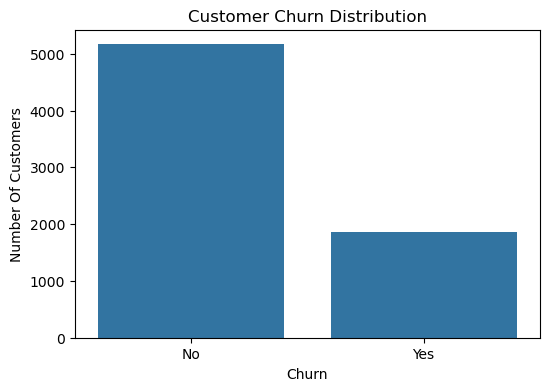

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number Of Customers")
plt.show()

### Does the customer's contract type have a relationship with churn?


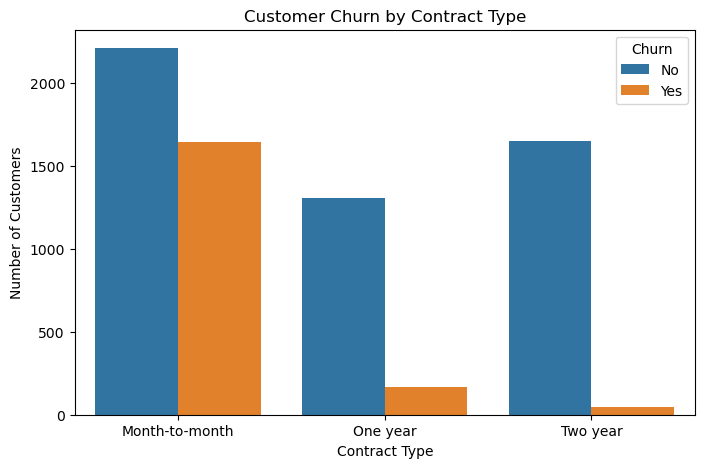

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Contract",hue="Churn")
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [51]:
contract_churn=pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


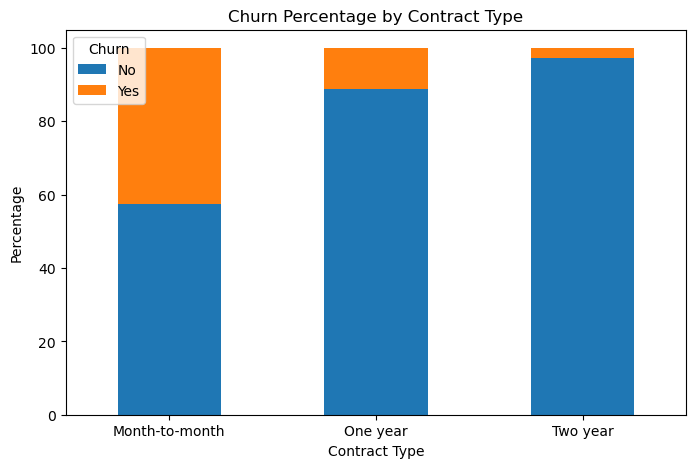

In [52]:
contract_churn.plot( kind="bar", stacked=True,figsize=(8, 5))
plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

In [53]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


In [54]:
normalize="index"

contract_churn

 ## Churn vs Tenure

### Now let's investigate:

### Do customers who have stayed longer tend to churn less?

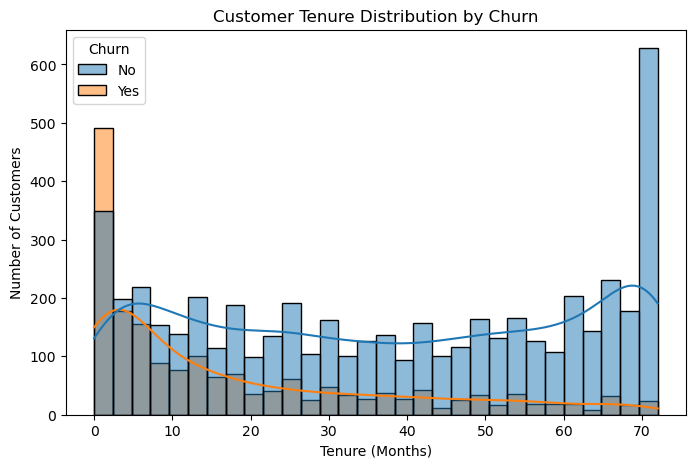

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df,x="tenure",hue="Churn",bins=30, kde=True)
plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [57]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.640782
Yes    18.088853
Name: tenure, dtype: float64

In [58]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

## Let's investigate Monthly Charges

### Do churned customers have different monthly charges?

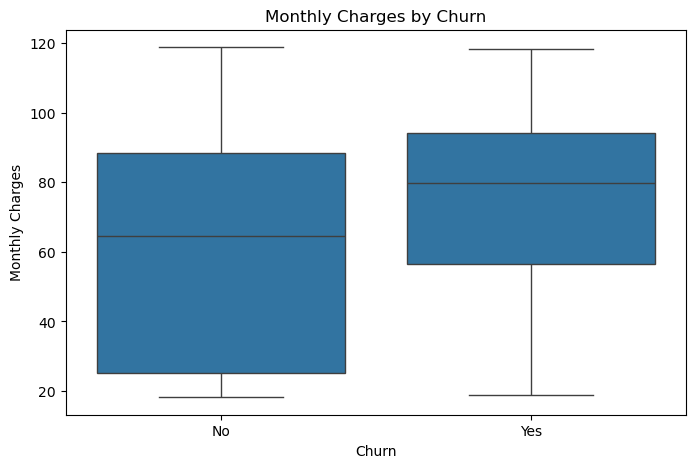

In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [60]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.344878
Yes    74.604308
Name: MonthlyCharges, dtype: float64

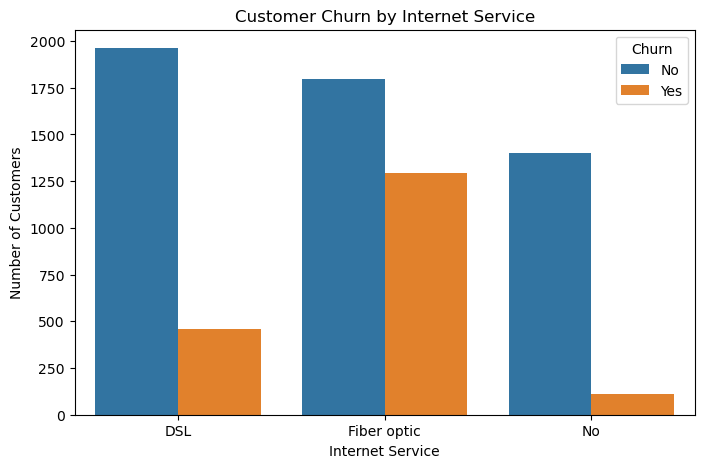

In [61]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="InternetService",hue="Churn")
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [62]:
internet_churn = pd.crosstab(df["InternetService"],df["Churn"],normalize="index")*100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.107896,18.892104
Fiber optic,58.220065,41.779935
No,92.791005,7.208995


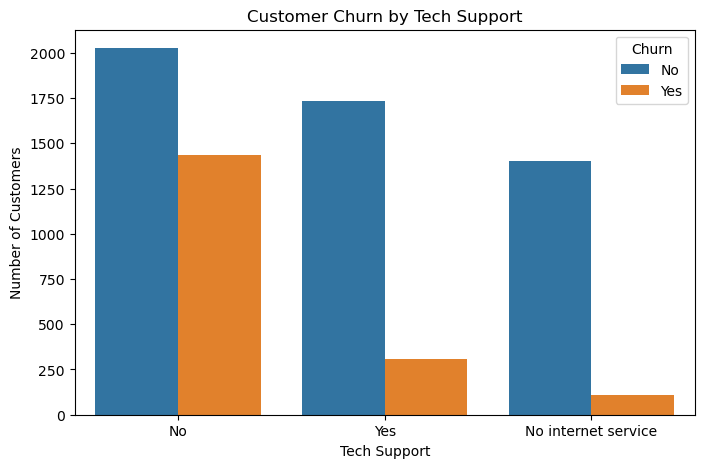

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="TechSupport",hue="Churn")
plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

In [64]:
techsupport_churn = pd.crosstab(df["TechSupport"],df["Churn"],normalize="index")*100
techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.499278,41.500722
No internet service,92.791005,7.208995
Yes,84.833659,15.166341


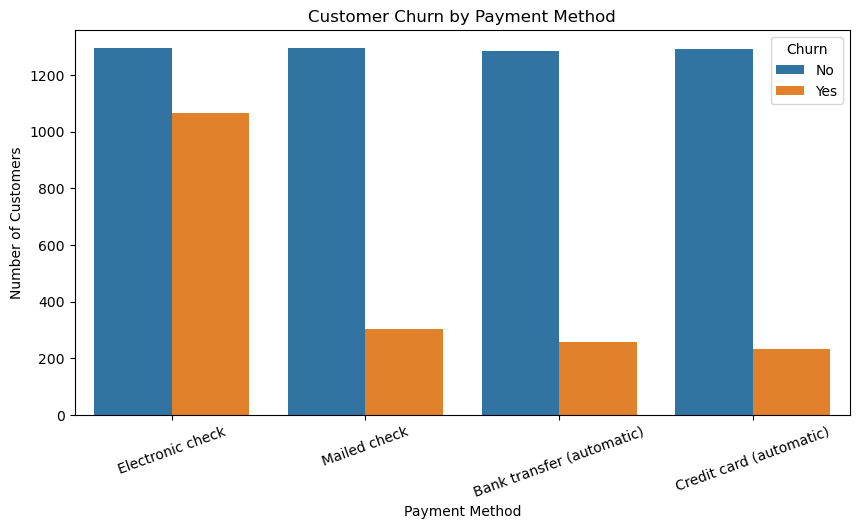

In [66]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df,x="PaymentMethod",hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [67]:
payment_churn = pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index")*100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.853752,45.146248
Mailed check,81.077694,18.922306


In [68]:
numeric_cols=["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]
correlation=df[numeric_cols].corr()
correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015349,0.219434,0.102243
tenure,0.015349,1.000000,0.245251,0.825595
MonthlyCharges,0.219434,0.245251,1.000000,0.650653
TotalCharges,0.102243,0.825595,0.650653,1.000000


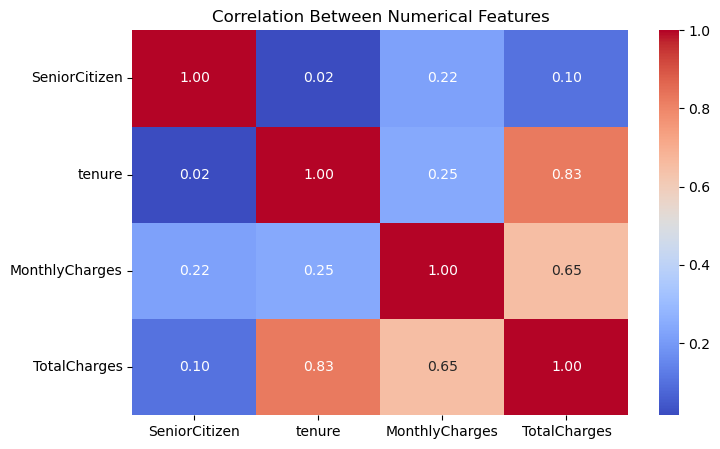

In [69]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()

In [70]:
categorical_cols = df.select_dtypes( include="object").columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [71]:
df[categorical_cols].nunique().sort_values()

gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
Churn               2
MultipleLines       3
InternetService     3
OnlineBackup        3
OnlineSecurity      3
DeviceProtection    3
TechSupport         3
StreamingMovies     3
StreamingTV         3
Contract            3
PaymentMethod       4
dtype: int64

In [72]:
df["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

# Step 4 — Prepare data for Machine Learning

In [73]:
x=df.drop("Churn",axis=1)
y=df["Churn"]

In [74]:
print("X shape:",x.shape)
print("y shape:",y.shape)

X shape: (7021, 19)
y shape: (7021,)


In [75]:
numeric_features=["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]

In [77]:
categorical_features = x.select_dtypes(include="object").columns.tolist()

In [78]:
print("Numerical features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [79]:
y = y.map({"No": 0,"Yes": 1})

In [80]:
y.value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

In [81]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [82]:
print("Training shape:",x_train.shape)
print("Testing shape:",y_test.shape)
print("\nTraining target:")
print(y_train.value_counts(normalize=True)*100)
print("\nTesting target:")
print(y_test.value_counts(normalize=True)*100)

Training shape: (5616, 19)
Testing shape: (1405,)

Training target:
Churn
0    73.557692
1    26.442308
Name: proportion, dtype: float64

Testing target:
Churn
0    73.523132
1    26.476868
Name: proportion, dtype: float64


## Build our preprocessing pipeline

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [85]:
# Numerical Pipeline
numeric_processor = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

In [87]:
# Categorical pipeline
categorical_processor = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [89]:
preprocessor = ColumnTransformer(transformers=[("num", numeric_processor, numeric_features),("cat", categorical_processor, categorical_features)]
)

In [91]:
print(x_train.shape)
print(x_test.shape)
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)

(5616, 19)
(1405, 19)
Churn
0    73.557692
1    26.442308
Name: proportion, dtype: float64
Churn
0    73.523132
1    26.476868
Name: proportion, dtype: float64


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [93]:
logistic_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000))]
)

In [94]:
logistic_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [99]:
y_pred=logistic_pipeline.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 0])

In [100]:
y_prob = logistic_pipeline.predict_proba(x_test)[:,1]
y_prob

array([0.75907243, 0.6166532 , 0.28492351, ..., 0.01984769, 0.66135204,
       0.17871613])

In [101]:
from sklearn.metrics import ( accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,confusion_matrix,classification_report)

In [102]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test, y_pred)
roc_auc=roc_auc_score(y_test,y_prob)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("ROC-AUC :",roc_auc)

Accuracy: 0.8021352313167259
Precision: 0.6598639455782312
Recall: 0.521505376344086
F1 Score: 0.5825825825825826
ROC-AUC : 0.8403009815861515


In [103]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405



In [104]:
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[933 100]
 [178 194]]


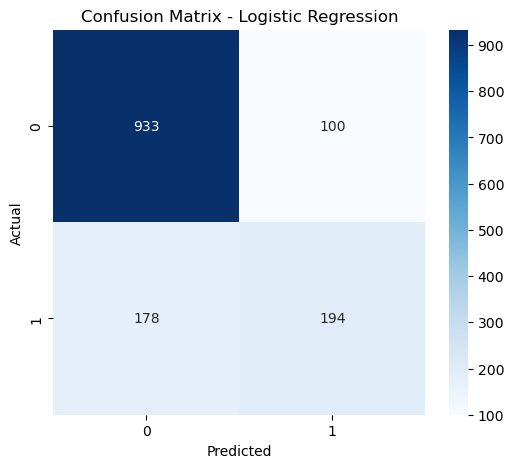

In [105]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [106]:
logistic_results = {"Model": "Logistic Regression","Accuracy":accuracy,"Precision":precision,"Recall":
            recall,"F1 Score": f1,"ROC-AUC": roc_auc}
logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8021352313167259,
 'Precision': 0.6598639455782312,
 'Recall': 0.521505376344086,
 'F1 Score': 0.5825825825825826,
 'ROC-AUC': np.float64(0.8403009815861515)}

In [107]:
from sklearn.ensemble import RandomForestClassifier

In [109]:
rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42))])

In [110]:
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [114]:
rf_pred = rf_pipeline.predict(x_test)
rf_prob = rf_pipeline.predict_proba(x_test)[:,1]

In [115]:
rf_accuracy=accuracy_score(y_test, rf_pred)
rf_precision=precision_score(y_test, rf_pred)
rf_recall=recall_score(y_test, rf_pred)
rf_f1=f1_score(y_test, rf_pred)
rf_roc_auc =roc_auc_score(y_test, rf_prob)
print("Random Forest")
print("----------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest
----------------
Accuracy : 0.7715302491103203
Precision: 0.5901060070671378
Recall   : 0.4489247311827957
F1 Score : 0.5099236641221374
ROC-AUC  : 0.8136729850420011


In [116]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.59      0.45      0.51       372

    accuracy                           0.77      1405
   macro avg       0.70      0.67      0.68      1405
weighted avg       0.76      0.77      0.76      1405



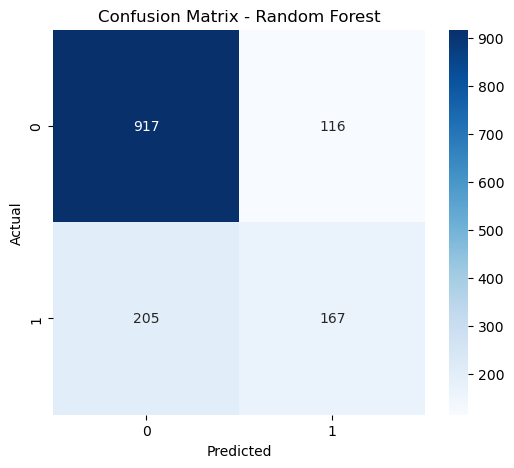

In [117]:
rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [118]:
results = pd.DataFrame([logistic_results,
{   "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc}
])
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802135,0.659864,0.521505,0.582583,0.840301
1,Random Forest,0.771530,0.590106,0.448925,0.509924,0.813673


In [119]:
from sklearn.ensemble import GradientBoostingClassifier

In [120]:
gb_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ))
    ]
)

In [122]:
gb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [123]:
gb_pred = gb_pipeline.predict(x_test)
gb_prob = gb_pipeline.predict_proba(x_test)[:, 1]

In [124]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_prob)
print("Gradient Boosting")
print("-------------------")
print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)
print("ROC-AUC  :", gb_roc_auc)

Gradient Boosting
-------------------
Accuracy : 0.8
Precision: 0.6585365853658537
Recall   : 0.5080645161290323
F1 Score : 0.5735963581183612
ROC-AUC  : 0.8388645140471953


In [125]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



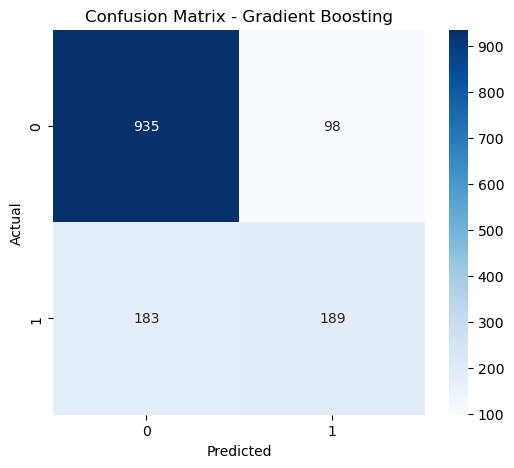

In [126]:
gb_cm = confusion_matrix(y_test, gb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Compare all 3 models

In [127]:
results = pd.DataFrame([
    logistic_results,
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": gb_accuracy,
        "Precision": gb_precision,
        "Recall": gb_recall,
        "F1 Score": gb_f1,
        "ROC-AUC": gb_roc_auc
    }
])

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802135,0.659864,0.521505,0.582583,0.840301
1,Random Forest,0.771530,0.590106,0.448925,0.509924,0.813673
2,Gradient Boosting,0.800000,0.658537,0.508065,0.573596,0.838865


In [128]:
results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802135,0.659864,0.521505,0.582583,0.840301
2,Gradient Boosting,0.800000,0.658537,0.508065,0.573596,0.838865
1,Random Forest,0.771530,0.590106,0.448925,0.509924,0.813673


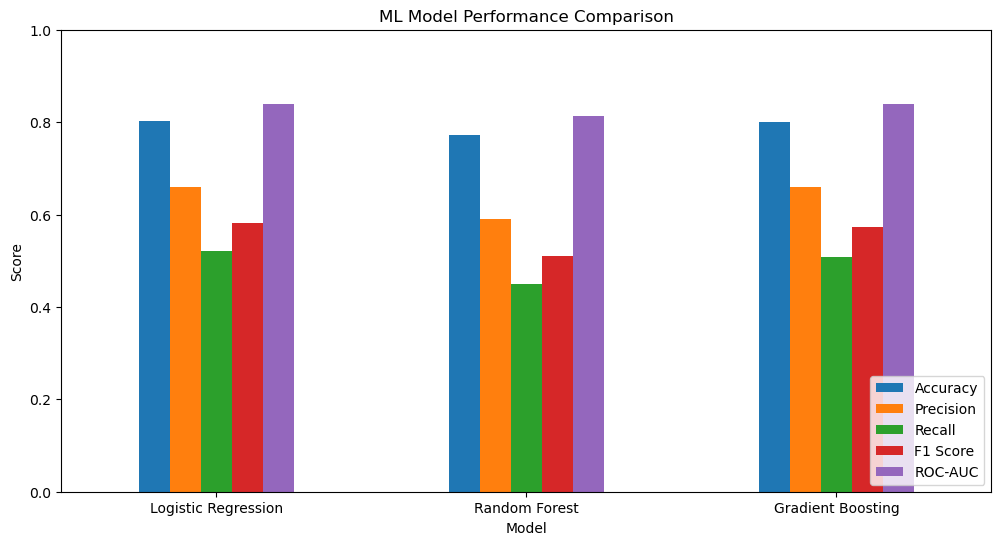

In [129]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

# Step 8 — Cross Validation

In [131]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    logistic_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)
print("Logistic Regression CV Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

Logistic Regression CV Scores: [0.625      0.59893048 0.59149723 0.57361377 0.60808436]
Mean F1: 0.5994251667788595


In [133]:
rf_cv_scores = cross_val_score(
    rf_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)
print("Random Forest CV Scores:", rf_cv_scores)
print("Mean F1:", rf_cv_scores.mean())

Random Forest CV Scores: [0.53149606 0.52690167 0.5546875  0.4939759  0.55474453]
Mean F1: 0.5323611323825684


In [135]:
gb_cv_scores = cross_val_score(
    gb_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)
print("Gradient Boosting CV Scores:", gb_cv_scores)
print("Mean F1:", gb_cv_scores.mean())

Gradient Boosting CV Scores: [0.59073359 0.60900901 0.61016949 0.55555556 0.58110517]
Mean F1: 0.5893145632328085


In [136]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV F1": [
        cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ]
})
cv_results

,Model,Mean CV F1
0,Logistic Regression,0.599425
1,Random Forest,0.532361
2,Gradient Boosting,0.589315


In [137]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV F1": [
        cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "Std F1": [
        cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

cv_results

,Model,Mean CV F1,Std F1
0,Logistic Regression,0.599425,0.017079
1,Random Forest,0.532361,0.022376
2,Gradient Boosting,0.589315,0.020159


In [140]:
from sklearn.model_selection import GridSearchCV
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [142]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
rf_grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(...
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [145]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [146]:
print("Best CV F1 Score:")
print(rf_grid.best_score_)

Best CV F1 Score:
0.5785530539514007


In [148]:
best_rf_model = rf_grid.best_estimator_

In [152]:
rf_tuned_pred = best_rf_model.predict(x_test)
rf_tuned_prob = best_rf_model.predict_proba(x_test)[:,1]

In [153]:
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(
    y_test,
    rf_tuned_pred
)
rf_tuned_recall = recall_score(
    y_test,
    rf_tuned_pred
)
rf_tuned_f1 = f1_score(
    y_test,
    rf_tuned_pred
)
rf_tuned_roc_auc = roc_auc_score(
    y_test,
    rf_tuned_prob
)

In [154]:
print("Accuracy :", rf_tuned_accuracy)
print("Precision:", rf_tuned_precision)
print("Recall   :", rf_tuned_recall)
print("F1 Score :", rf_tuned_f1)
print("ROC-AUC  :", rf_tuned_roc_auc)

Accuracy : 0.798576512455516
Precision: 0.656140350877193
Recall   : 0.5026881720430108
F1 Score : 0.5692541856925418
ROC-AUC  : 0.8352421176446096


In [155]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_tuned_pred)

print(cm)

[[935  98]
 [185 187]]


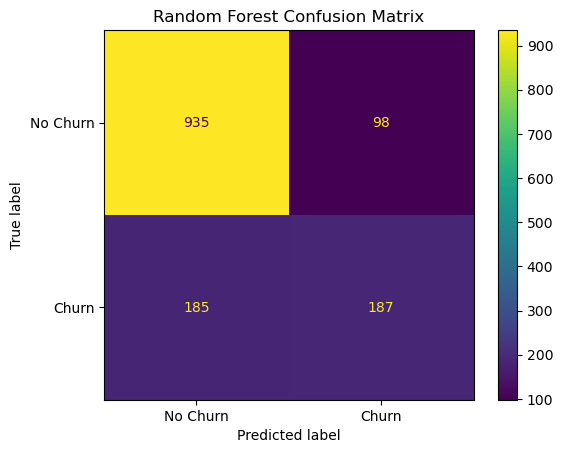

In [156]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [157]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_tuned_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1033
       Churn       0.66      0.50      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.70      0.72      1405
weighted avg       0.79      0.80      0.79      1405



In [158]:
rf_tuned_prob

array([0.70544619, 0.44357493, 0.50622013, ..., 0.00893083, 0.5590136 ,
       0.14843552])

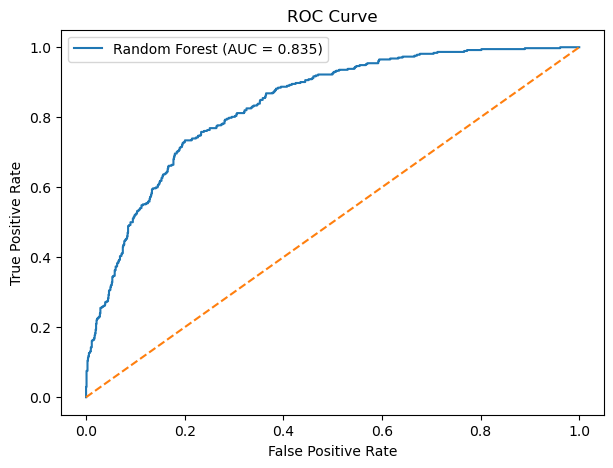

In [159]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_tuned_prob
)

auc_score = roc_auc_score(
    y_test,
    rf_tuned_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [160]:
rf_model = best_rf_model.named_steps["model"]

In [161]:
feature_names = (
    best_rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [162]:
importances = rf_model.feature_importances_

In [163]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [164]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [165]:
feature_importance.head(15)

,Feature,Importance
1,num__tenure,0.145462
3,num__TotalCharges,0.130781
36,cat__Contract_Month-to-month,0.091456
2,num__MonthlyCharges,0.083659
16,cat__InternetService_Fiber optic,0.055293
18,cat__OnlineSecurity_No,0.050058
27,cat__TechSupport_No,0.044363
43,cat__PaymentMethod_Electronic check,0.038176
38,cat__Contract_Two year,0.028916
15,cat__InternetService_DSL,0.020124


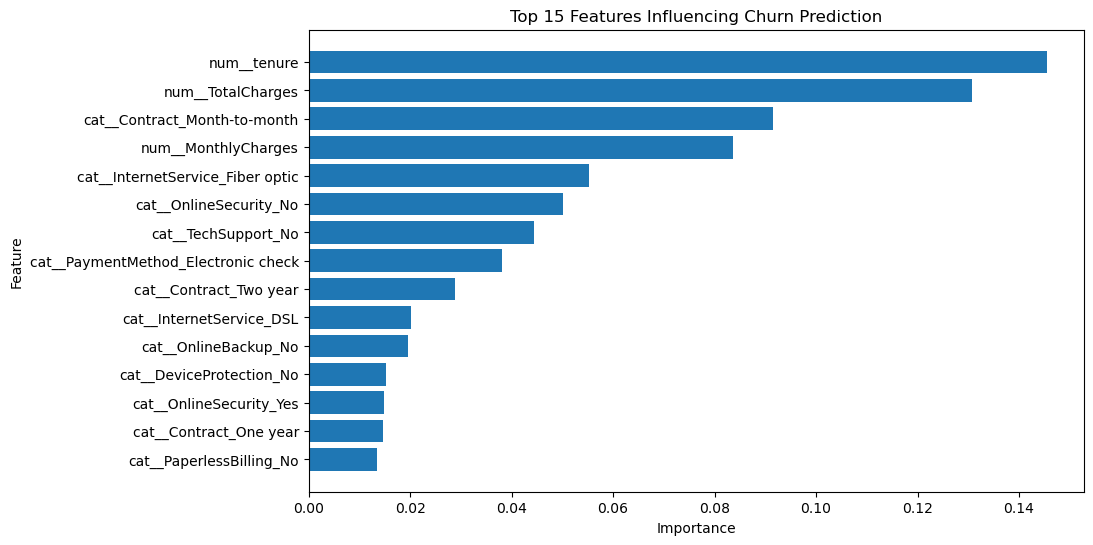

In [166]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Churn Prediction")
plt.gca().invert_yaxis()

plt.show()

In [167]:
import joblib
joblib.dump(
    best_rf_model,
    "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [168]:
import os
print(os.path.exists("customer_churn_model.pkl"))

True
